# Plotting with seaborn and pyplot

- We will visualize this data using matplotlib--a comprehensive plotting library in Python.  It provides a low-level interface for creating plots, including the ability to manage every aspect of the plot from the axes, to colors, labels, fonts, figure dimensions, paneling, etc.
- Pyplot is a module within matplotlib that provides a simple interface for creating plots that doesn't require you to manage all the low-level details of the plot.
- Seaborn is another popular plotting library that extends matplotlib even further, making it easier to create many common tabular data visualizations quickly.

## Review of pandas

- This section uses a dataset from fivethirtyeight that gives the number of births in the US day by day from 2000 to 2016.
- Using our notes from yesterday, let's load the data and inspect it.

Exercises
1. Load the csv file called `births.csv` in the data directory into a pandas dataframe.
2. Inspect the column names.
3. Inspect the dimensions of the dataframe.
4. Inspect the first few rows of the dataframe.
5. Inspect the last few rows of the dataframe.


## Our first plot



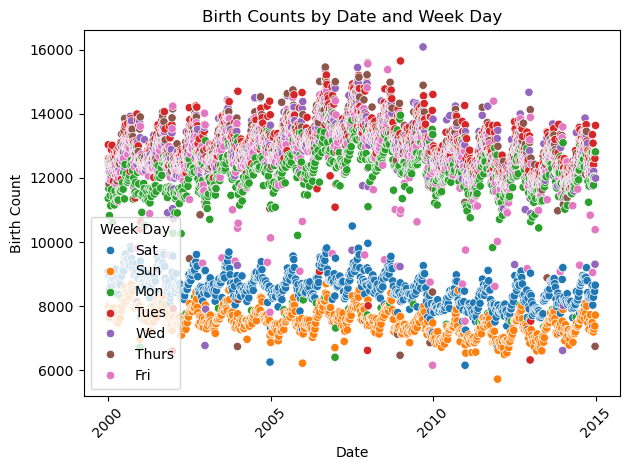

In [7]:

import pandas as pd # Tabular data
import matplotlib.pyplot as plt # Plotting engine
import seaborn as sns # High-level plotting

# Load the data from the data directory
births = pd.read_csv("data/births.csv")

# Starts up a figure with matplotlib
plt.figure()


# Use seaborn to initialize the main plot


# Puts a scatter plot on the figure
sns.scatterplot(
    # x axis should be the date
    x = 'date',
    # y axis should be the birth count on that date
    y = 'birth.count',
    # each week day gets a different color
    hue = 'week_day',
    # data from births dataframe
    data = births,
    # one of many built-in color palettes
    palette = 'tab10'
    )

# Customize plot wih matplotlib

# Change the title
plt.title('Birth Counts by Date and Week Day')
# X axis label
plt.xlabel('Date')
# Y axis label
plt.ylabel('Birth Count')
# Legend title
plt.legend(title='Week Day')

# Customize x axis tick marks
plt.xticks(
    # Make ticks at these dates
    ticks = ["2000-01-01", "2005-01-01", "2010-01-01", "2015-01-01"], 
    # Label them with these labels
    labels = ["2000", "2005", "2010", "2015"], 
    # Rotate the labels 45 degrees for readability
    rotation=45)

# Auto-adjust layout to prevent overlapping elements
plt.tight_layout()

# Show the plot
# This is actually not necessary in a Jupyter notebook, but you would need it in a script.
plt.show()



## Plotting exercises
In the plot above, it looks like there is a seasonal pattern to the number of births.  In this exercise, you will try to plot this explicitly.


1. Use seaborn's `barplot` function to plot the number of births by month across all years.  You'll have to read the documentation!
2. The `birth.count` axis is not ideal because the difference between seasons is small by comparison to the total number of births.  Use the `ylim` function for pyplot to set the y-axis limits to something more informative.
3. Great!  Now clean up your plot.  Add a title and axis labels.  Pick your favorite colors.
4. Set the month axis ticks to be the months of the year.

So what do you think, is there a compelling seasonal pattern?  Consider the size of the error bars too.

In [27]:
# Your barplot here

# Statistical modeling
- A model is a mathematical expression that describes the relationship between variables.  A statistical model usually involves randomness too.
- The linear model is the workhorse of statistical modeling.  It takes some outcome, called a response, and assumes that on average, the predictors are linearly related to it.
- Linear means that an increase in the predictor of size 1 will increase the response by a corresponding constant amount.  The coefficients in the model determine the direction and magnitude of the amount.

## The Iris dataset
Now we will use a data set about iris anatomy to demonstrate linear modeling.  The dataset, called `iris.csv`, contains measurements of sepal length, sepal width, petal length, and petal width for three species of iris flowers: Iris setosa, Iris versicolor, and Iris virginica. The original dataset was collected by the British statistician and biologist Ronald A. Fisher in 1936 and has since become a classic dataset for testing machine learning algorithms.


Let's take a look at the data

In [28]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Read in the iris dataset
iris = pd.read_csv("data/iris.csv")


( # allows us to use multi-line formatting
    
# Rename columns to be more "Pythonic"
iris.rename(
    columns =  { # Note we're starting a dictionary 
    "Sepal.Length" : "sepal_length" , # convert "A" : "a"
    "Sepal.Width" : "sepal_width",
    "Petal.Length" : "petal_length",
    "Petal.Width" : "petal_width",
    "Species": "species"},
    # Modify the iris dataframe instead of making a new one
    inplace = True)
)

# Show the first few rows 
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Questions about the irises

- What is the relationship between sepal length and sepal width?  Petal length and petal width?
- Is there also a relationship between sepal size and petal size?
- How do these relationships vary by species, if at all?


## Visualize the data before modeling
You should always plot your data before modeling it.  As an exercise, take a minute and make a simple scatter plot with seaborn.

In [ ]:
# Your scatter plot here

## Our first linear model
- It's clear that petal length and petal width have a linear relationship.  And that this relationship is different for the three species.
- Let's fit a linear model to the data.  We'll use the `statsmodels` library to fit the model.


### Formulas
The formula syntax for the linear model is:
response ~ predictor1 + predictor2 + ... + predictorN

- The tilde `~` is used to separate the response from the predictors.
- The `+` operator is used to add more predictors to the model.

We use formulas to tell statsmodels what model to fit.

In [29]:
# Model petal length as a function of petal width
lm_result = smf.ols( 'petal_length ~ petal_width ', data = iris).fit()
# Show the model summary
lm_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           petal_length   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     1882.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.68e-86
Time:                        11:03:36   Log-Likelihood:                -101.18
No. Observations:                 150   AIC:                             206.4
Df Residuals:                     148   BIC:                             212.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.0836      0.073     14.850      0.000       0.939       1.228
petal_width     2.2299      0.051     43.387      0.000       2.128       2.332
==============================================================================
Omnibus:                        2.438   Durbin-Watson:                   1.430
Prob(Omnibus):                  0.295   Jarque-Bera (JB):                1.966
Skew:                           0.211   Prob(JB):                        0.374
Kurtosis:                       3.369   Cond. No.                         3.70
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpreting the model
The model summary is a table that contains the coefficients, standard errors, t-values, and p-values for the model.

- OLS stands for Ordinary Least Squares.  It's a method for fitting a linear model to data.
- The coefficients are the values of the linear relationship between the response and the predictors.
- The standard errors are the standard deviations of estimates for the coefficients.
- The t-values are the coefficients divided by the standard errors.  They are used to test the null hypothesis that the coefficient is zero.
- The p-values are the probabilities of observing a t-value at least as extreme as the one observed, assuming the null hypothesis is true.
- The R-squared value is the proportion of the variance in the response that is explained by the predictors.
- The Adjusted R-squared value is the R-squared value, but with a penalty for the number of predictors in the model.  It's useful for comparing models with different numbers of predictors and assessing whether the additional predictors are "worth their weight" in explaining the response relative to the complexity they add.
- The F-statistic is a measure of the overall performance of the model.  Larger indicates that the model explains the data much better than a model with only an intercept.
- The p-value for the F-statistic is the probability of observing an F-statistic at least as large as the one observed, assuming the null hypothesis (that all the coefficients are zero) is true.
- The columns labeled `[0.025` and `0.975]` are the lower and upper bounds of the 95% confidence interval for the coefficients.

### Interpreting the coefficients
The coefficients are the values of the linear relationship between the response and the predictors.

- The intercept is the value of the response when all the predictors are zero.
- The predictor coefficients are the values of the response when the predictor increases by 1 unit.

## Adding a regression line to the plot
- We can add a regression line to the plot using the `lm_result` object.
- We can use the `predict` method to get the predicted values of the response for each value of the predictor.
- We can then use the `plot` method from pyplot to add a line to the seaborn plot.

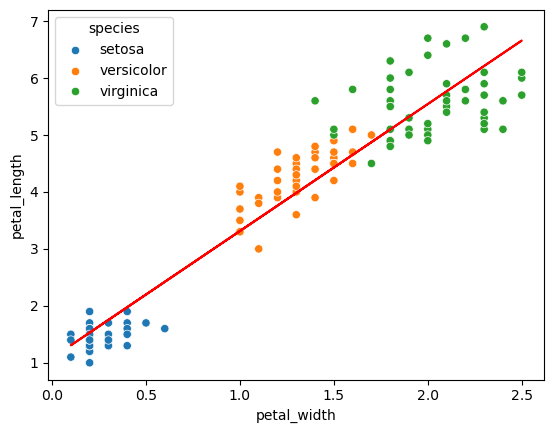

In [31]:
y = lm_result.predict(iris)
x = iris['petal_width']

sns.scatterplot(x='petal_width', y='petal_length', data=iris, hue='species')

plt.plot(x, y, color='red')



## Interaction terms

- Sometimes the relationship between the response and a predictor depends on the value of another predictor.  In this case, the species.
- We can tell statsmodels to find a different coefficient for each value of the species predictor by using the `*` operator in the formula.

`y ~ x1 * x2`
is shorthand for
`y ~ x1 + x2 + x1 * x2` 

Let's see what happens when we apply this change.

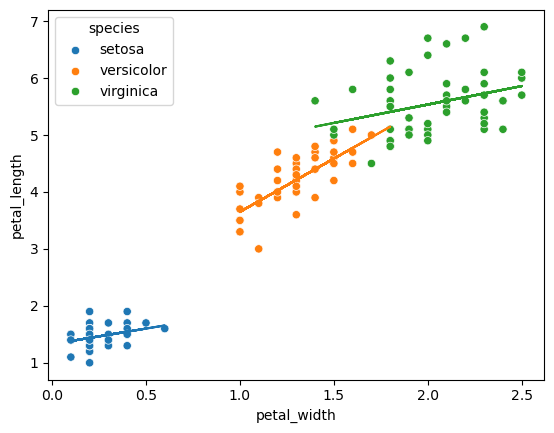

In [39]:
# Model petal length as a function of petal width
lm_result = smf.ols( 'petal_length ~ petal_width * species ', data = iris).fit()

sns.scatterplot(x='petal_width', y='petal_length', data=iris, hue='species')

# We need extract the predictions for each species and plot them
# You could do this with a for loop, but we'll just do it manually

# Extract the data for each species
iris_setosa = iris[iris['species'] == 'setosa']
iris_versicolor = iris[iris['species'] == 'versicolor']
iris_virginica = iris[iris['species'] == 'virginica']

# Make predictions for each species
y_pred_setosa = lm_result.predict(iris_setosa)
y_pred_versicolor = lm_result.predict(iris_versicolor)
y_pred_virginica = lm_result.predict(iris_virginica)

# Plot the predictions for each species
plt.plot(iris_setosa['petal_width'], y_pred_setosa)
plt.plot(iris_versicolor['petal_width'], y_pred_versicolor)
plt.plot(iris_virginica['petal_width'], y_pred_virginica)

In [37]:
lm_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           petal_length   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     681.9
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.52e-98
Time:                        11:26:09   Log-Likelihood:                -57.145
No. Observations:                 150   AIC:                             126.3
Df Residuals:                     144   BIC:                             144.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             1.3276      0.131     10.139      0.000       1.069       1.586
species[T.versicolor]                 0.4537      0.374      1.214      0.227      -0.285       1.192
species[T.virginica]                  2.9131      0.406      7.175      0.000       2.111       3.716
petal_width                           0.5465      0.490      1.115      0.267      -0.422       1.515
petal_width:species[T.versicolor]     1.3228      0.555      2.382      0.019       0.225       2.420
petal_width:species[T.virginica]      0.1008      0.525      0.192      0.848      -0.937       1.138
==============================================================================
Omnibus:                       17.046   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.218
Skew:                           0.635   Prob(JB):                     5.51e-06
Kurtosis:                       4.504   Cond. No.                         63.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Exercises

Explore one or more of the other questions we asked about the irises.  For example, how does the relationship between sepal length and sepal width vary by species?